In [47]:
# loading the merged dataset
import pandas as pd;
import numpy as np;

# load the data
data = pd.read_json(r"E:\RSXS\Study\project\ParticulateMatterApp\data\ML\merged_record.json");
print(data.head());
print("\nShape:");
print(data.shape);

print("\nColumns:");
print(data.columns);

                       hour   pm25  temperature   humidity  \
0  2026-06-30T21:00:00.000Z    NaN          NaN        NaN   
1  2026-06-30T22:00:00.000Z    NaN          NaN        NaN   
2  2026-06-30T23:00:00.000Z    NaN          NaN        NaN   
3  2026-07-01T00:00:00.000Z  66.26    21.550000  82.574999   
4  2026-07-01T01:00:00.000Z  63.54    22.033333  87.283333   

                        site  count  meanSpeed  meanDuration   meanTPI  \
0                       None      4   5.558071       2985.75  1.154125   
1                       None      4   5.363622       3075.00  1.188600   
2                       None      4   5.082098       3253.00  1.257350   
3  Kireka, Kira Municipality      4   6.396200       2613.00  1.010000   
4  Kireka, Kira Municipality      4   6.657236       2540.25  0.981950   

   minTPI  minTPIId  maxTPI  maxTPIId  
0  0.8419      4332  1.3610      4334  
1  0.8632      4336  1.3880      4337  
2  0.9032      4341  1.4609      4343  
3  0.7801      4345  1

In [49]:
# checking what is missing and where exaclty
print(data.isnull().sum());

hour             0
pm25            48
temperature     38
humidity        38
site            38
count            0
meanSpeed        0
meanDuration     0
meanTPI          0
minTPI           0
minTPIId         0
maxTPI           0
maxTPIId         0
dtype: int64


In [59]:
# converting hour timestamp into a python date object.
model_data["hour"] = pd.to_datetime(model_data["hour"]);
print(model_data.dtypes);

hour            datetime64[ns, UTC]
pm25                        float64
temperature                 float64
humidity                    float64
site                         object
count                         int64
meanSpeed                   float64
meanDuration                float64
meanTPI                     float64
minTPI                      float64
minTPIId                      int64
maxTPI                      float64
maxTPIId                      int64
dtype: object


In [61]:
#creating time features
model_data["hour_of_day"]=(model_data["hour"].dt.hour);
model_data["day_of_week"]=(model_data["hour"].dt.dayofweek);
model_data["is_weekend"]=(model_data["day_of_week"]>=5).astype(int);

In [55]:
print(model_data.isnull().sum()); 

hour            0
pm25            0
temperature     0
humidity        0
site            0
count           0
meanSpeed       0
meanDuration    0
meanTPI         0
minTPI          0
minTPIId        0
maxTPI          0
maxTPIId        0
dtype: int64


In [63]:
#creating time features
model_data["hour_of_day"]=(model_data["hour"].dt.hour);
model_data["day_of_week"]=(model_data["hour"].dt.dayofweek);
model_data["is_weekend"]=(model_data["day_of_week"]>=5).astype(int);

In [65]:
# verification of time features
print(model_data[["hour","hour_of_day","day_of_week","is_weekend"]].head());

                       hour  hour_of_day  day_of_week  is_weekend
3 2026-07-01 00:00:00+00:00            0            2           0
4 2026-07-01 01:00:00+00:00            1            2           0
5 2026-07-01 02:00:00+00:00            2            2           0
6 2026-07-01 03:00:00+00:00            3            2           0
7 2026-07-01 04:00:00+00:00            4            2           0


In [67]:
# my feature matrix, am combining traffic and meteorological info to predict pm2.5
X = model_data [
    [
        "temperature",
        "humidity",
        "meanSpeed",
        "meanDuration",
        "meanTPI",
        "hour_of_day",
        "day_of_week",
        "is_weekend"
    ]
];

In [69]:
y = model_data["pm25"];

In [71]:
# verifying my predictors and my target variable
print(X.shape);
print(y.shape);

print(X.head());
print(y.head());

(696, 8)
(696,)
   temperature   humidity  meanSpeed  meanDuration   meanTPI  hour_of_day  \
3    21.550000  82.574999   6.396200       2613.00  1.010000            0   
4    22.033333  87.283333   6.657236       2540.25  0.981950            1   
5    21.925000  87.991667   5.642900       2980.25  1.151975            2   
6    21.166667  97.739999   5.176372       3093.25  1.195600            3   
7    20.900000  98.600000   5.644851       2982.00  1.152675            4   

   day_of_week  is_weekend  
3            2           0  
4            2           0  
5            2           0  
6            2           0  
7            2           0  
3     66.26
4     63.54
5     60.90
6     88.15
7    107.60
Name: pm25, dtype: float64


In [107]:
# splitting my datasets
from sklearn.model_selection import train_test_split;
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42);
print("Training Features:", X_train.shape);

Training Features: (556, 8)


In [109]:
# importing the HistGradientBoosting regressor model.
from sklearn.ensemble import HistGradientBoostingRegressor;

# create an instance of the rfr with 200Ts, same Tree rebuild, all cpu use
gbr = HistGradientBoostingRegressor(
    max_iter=500,                     # buid 300 boosting stages
    learning_rate=0.05,                # control how fast or slow model runs, starting with 0.1
    max_depth=10,                     # how complex can each tree become.
    random_state=42                   # make results reproduceable
);
gbr.fit(X_train, y_train);
print("Hist Gradient Boosting Regressor Model trained successfully");

Hist Gradient Boosting Regressor Model trained successfully


In [111]:
# generating predictions
y_pred_gbr = gbr.predict(X_test);
print(y_pred_gbr[:10]);

[ 17.97116215  35.05706768  30.5293686  101.68443696 109.56224366
 137.95533588  33.10831874  20.05789383  26.99929194 118.9749764 ]


In [119]:
# Evaluating Model
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score);
mae = mean_absolute_error(y_test,y_pred_gbr);
rmse = np.sqrt(mean_squared_error(y_test,y_pred_gbr));
r2= r2_score(y_test,y_pred_gbr);
print("HGBR MAE :", mae);
print("HGBR RMSE :", rmse);
print("HGBR R2 :", r2);

HGBR MAE : 23.16444367928706
HGBR RMSE : 31.70490075011154
HGBR R2 : 0.4752964797623387


In [121]:
print(model_data["pm25"].describe());

count    696.000000
mean      75.971336
std       47.819406
min        6.930000
25%       35.925000
50%       63.015000
75%      112.237500
max      190.150000
Name: pm25, dtype: float64


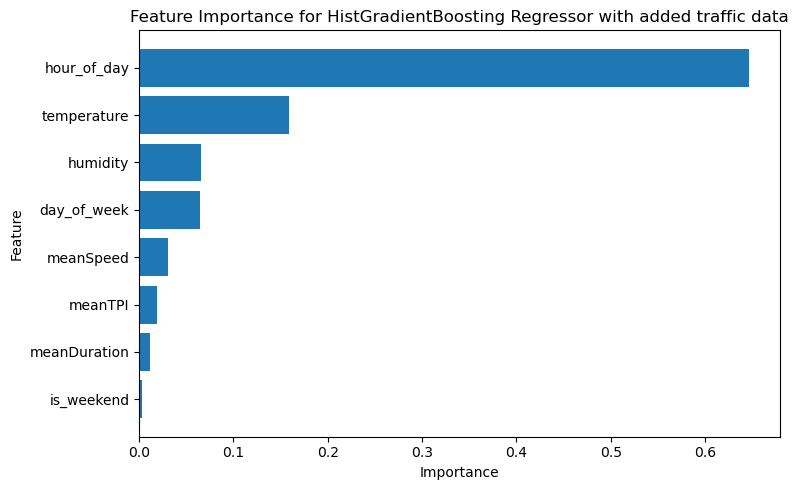

In [127]:
# feature importance figure
import matplotlib.pyplot as plt;
feature_importance = feature_importance.sort_values(by="Importance", ascending=True);
plt.figure(figsize=(8,5));
plt.barh(feature_importance["Feature"], feature_importance["Importance"]);
plt.xlabel("Importance");
plt.ylabel("Feature");
plt.title("Feature Importance for HistGradientBoosting Regressor with added traffic data");
plt.tight_layout();
plt.show();

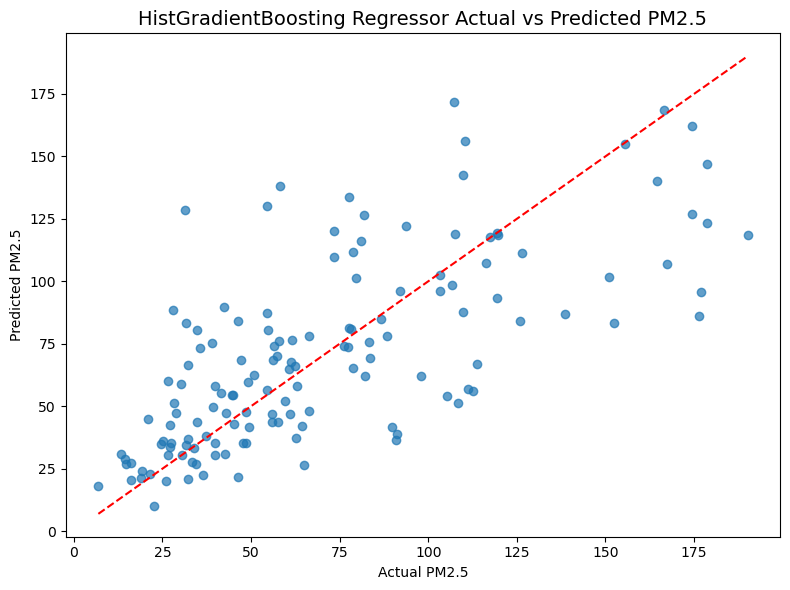

In [135]:
# Checking the quality of predictions
plt.figure(figsize=(8,6));
plt.scatter(y_test, y_pred_gbr, alpha=0.7);
plt.plot([y_test.min(), y_test.max()],[y_test.min(),y_test.max()],"r--");
plt.title("HistGradientBoosting Regressor Actual vs Predicted PM2.5", fontsize=14);
plt.xlabel("Actual PM2.5");
plt.ylabel("Predicted PM2.5");
plt.tight_layout();
plt.show();

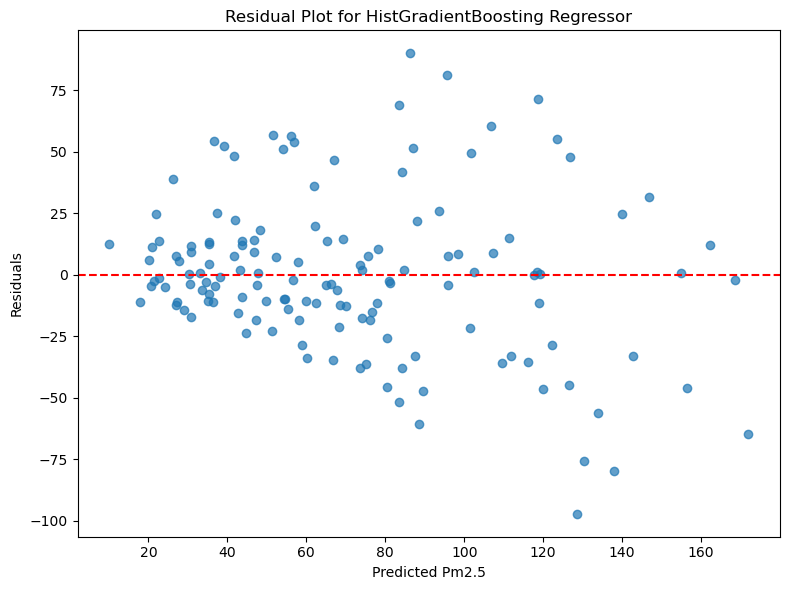

In [137]:
#residual plot to check if errords are random or they follow some pattern.
residuals = y_test - y_pred_gbr;
plt.figure(figsize=(8,6));
plt.scatter(y_pred_gbr, residuals,alpha=0.7);
plt.axhline(y=0, color='red',linestyle='--');

plt.xlabel("Predicted Pm2.5");
plt.ylabel("Residuals");
plt.title("Residual Plot for HistGradientBoosting Regressor");
plt.tight_layout();
plt.show();